<a href="https://colab.research.google.com/github/mahirshadid2point0/machine-learning-cse-4877-4878/blob/main/week4_c1_c2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Week 4: Machine Learning and Data Mining Lab
# Class 1: Similarity and Dissimilarity Measures - Euclidean distance, Manhattan distance, cosine similarity, distance matrices, and the effect of scaling.
# Class 2: EDA and Statistical Analysis - dataset inspection, missing values, class distribution, histograms, boxplots, correlation, and interpreting findings.

In [2]:
import numpy as np
from scipy.spatial.distance import euclidean, cityblock, cosine
from sklearn.metrics import pairwise_distances

In [8]:
# CLASS 1

A = np.array([1, 2, 3])
B = np.array([2, 4, 6])
C = np.array([3, 2, 1])

print("A =", A)
print("B =", B)
print("C =", C)

A = [1 2 3]
B = [2 4 6]
C = [3 2 1]


In [4]:
print("Euclidean distance:", euclidean(A, B))
print("Manhattan distance:", cityblock(A, B))
print("Cosine similarity:", 1 - cosine(A, B))

Euclidean distance: 3.7416573867739413
Manhattan distance: 6
Cosine similarity: 1.0


In [5]:
X = np.array([A, B, C])

print("Euclidean Distance Matrix:")
print(pairwise_distances(X, metric="euclidean").round(2))

Euclidean Distance Matrix:
[[0.   3.74 2.83]
 [3.74 0.   5.48]
 [2.83 5.48 0.  ]]


In [6]:
for metric in ["euclidean", "manhattan", "cosine"]:
    print("\n", metric.upper())
    print(pairwise_distances(X, metric=metric).round(2))


 EUCLIDEAN
[[0.   3.74 2.83]
 [3.74 0.   5.48]
 [2.83 5.48 0.  ]]

 MANHATTAN
[[0. 6. 4.]
 [6. 0. 8.]
 [4. 8. 0.]]

 COSINE
[[0.   0.   0.29]
 [0.   0.   0.29]
 [0.29 0.29 0.  ]]


In [7]:
print("Original distance:", euclidean(A, B))

A_scaled = A * [100, 1, 1]
B_scaled = B * [100, 1, 1]

print("Distance after scaling one feature:",
      euclidean(A_scaled, B_scaled))

Original distance: 3.7416573867739413
Distance after scaling one feature: 100.0649788887201


In [9]:
# CLASS 2

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

df["target_name"] = df["target"].map(dict(enumerate(data.target_names)))

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [10]:
print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes.value_counts())

print("\nMissing values:")
print(df.isna().sum().sum())

print("\nClass distribution:")
print(df["target_name"].value_counts())

Dataset shape: (569, 32)

Data types:
float64    30
int64       1
object      1
Name: count, dtype: int64

Missing values:
0

Class distribution:
target_name
benign       357
malignant    212
Name: count, dtype: int64


In [13]:
print("Missing rate (%):")
print((df.isna().sum() / len(df) * 100).round(2))

print("\nClass proportions:")
print((df["target_name"].value_counts(normalize=True) * 100).round(2))

Missing rate (%):
mean radius                0.0
mean texture               0.0
mean perimeter             0.0
mean area                  0.0
mean smoothness            0.0
mean compactness           0.0
mean concavity             0.0
mean concave points        0.0
mean symmetry              0.0
mean fractal dimension     0.0
radius error               0.0
texture error              0.0
perimeter error            0.0
area error                 0.0
smoothness error           0.0
compactness error          0.0
concavity error            0.0
concave points error       0.0
symmetry error             0.0
fractal dimension error    0.0
worst radius               0.0
worst texture              0.0
worst perimeter            0.0
worst area                 0.0
worst smoothness           0.0
worst compactness          0.0
worst concavity            0.0
worst concave points       0.0
worst symmetry             0.0
worst fractal dimension    0.0
target                     0.0
target_name          

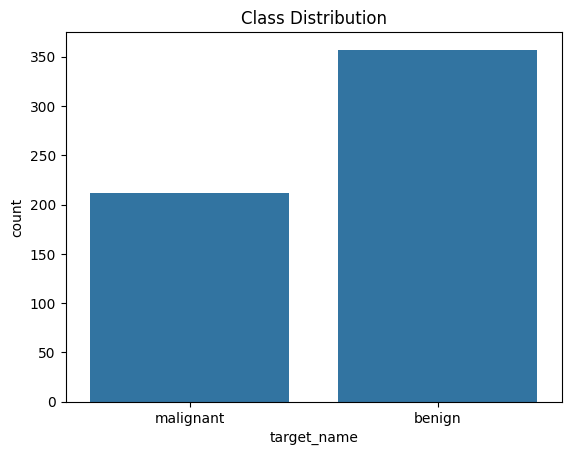

In [15]:
sns.countplot(data=df, x="target_name")
plt.title("Class Distribution")
plt.show()

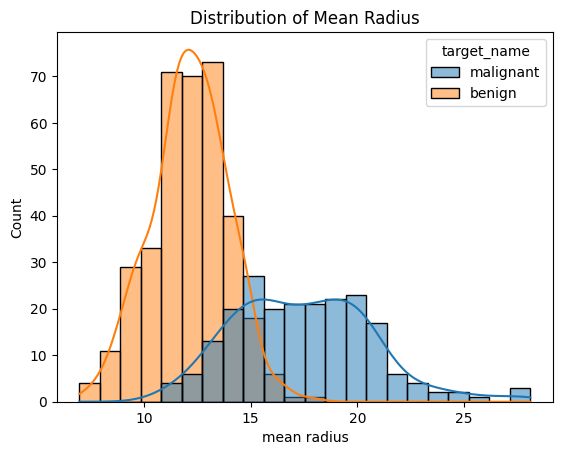

In [17]:
sns.histplot(data=df, x="mean radius", hue="target_name", kde=True)
plt.title("Distribution of Mean Radius")
plt.show()

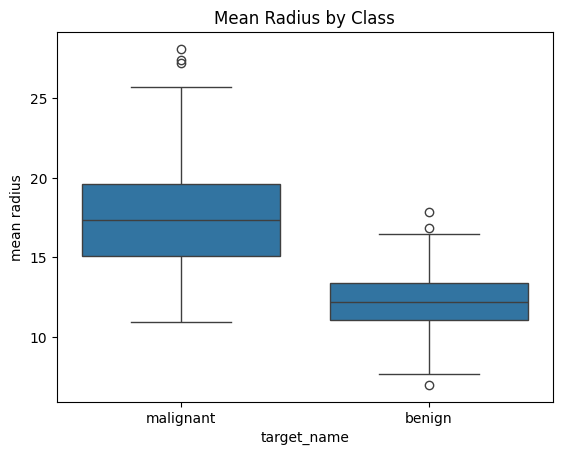

In [18]:
sns.boxplot(data=df, x="target_name", y="mean radius")
plt.title("Mean Radius by Class")
plt.show()

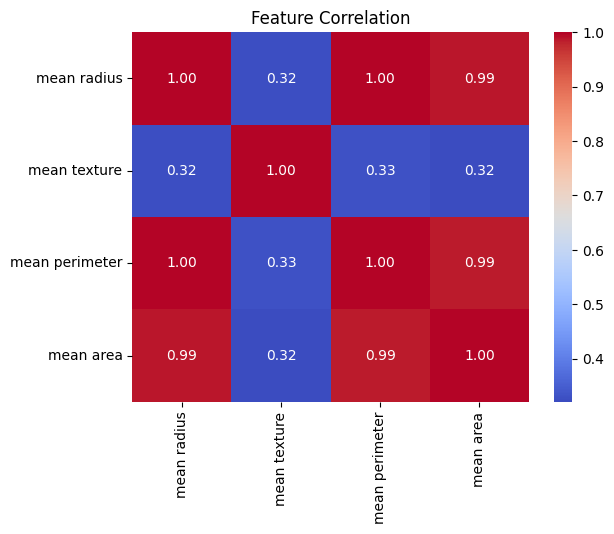

In [19]:
features = ["mean radius", "mean texture", "mean perimeter", "mean area"]

corr = df[features].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation")
plt.show()